# Hidden Markov Models

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook implements a discrete Hidden Markov Model (HMM) to infer latent weather states (Rain / No Rain) from noisy observations (Umbrella / No Umbrella). It demonstrates the fundamental algorithms of filtering (Forward) and decoding (Viterbi), followed by a multi-step forecast of the hidden state distribution.

**Key Techniques & Libraries:**
- Custom HMM class with Forward and Viterbi algorithms
- Numerical stability via step-wise normalization
- Transition matrix forecasting for stationary distributions
- `numpy`, `pandas`, `matplotlib`, `seaborn`

**Data Source:**
Synthetic dataset generated from predefined transition and emission probability matrices.

In [1]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Tuple, Dict, Union

# Reproducibility
np.random.seed(42)

# High-DPI visualizations for retina displays
%config InlineBackend.figure_format = 'retina'

# Set global plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists if we want to save figures later
Path("plots").mkdir(exist_ok=True)

In [2]:
# %% HMM Class Definition
class HMM:
    """
    A Hidden Markov Model for discrete states and observations.

    Attributes:
        states (List[str]): Names of the hidden states.
        observations (List[str]): Names of the observable emissions.
        start_prob (np.ndarray): Initial state distribution P(R_0). Shape (N,).
        trans_prob (np.ndarray): Transition matrix P(R_t | R_{t-1}). Shape (N, N).
        emission_prob (np.ndarray): Emission matrix P(U_t | R_t). Shape (N, M).
        state_index (Dict[str, int]): Mapping from state name to index.
        obs_index (Dict[str, int]): Mapping from observation name to index.
    """
    def __init__(
        self,
        states: List[str],
        observations: List[str],
        start_prob: Union[List[float], np.ndarray],
        trans_prob: Union[List[List[float]], np.ndarray],
        emission_prob: Union[List[List[float]], np.ndarray]
    ):
        self.states = states
        self.observations = observations
        self.n_states = len(states)
        self.n_obs = len(observations)

        self.start_prob = np.array(start_prob, dtype=np.float64)
        self.trans_prob = np.array(trans_prob, dtype=np.float64)
        self.emission_prob = np.array(emission_prob, dtype=np.float64)

        self.state_index = {state: i for i, state in enumerate(states)}
        self.obs_index = {obs: i for i, obs in enumerate(observations)}

        # Input validation (professional safeguard)
        assert self.start_prob.shape == (self.n_states,), "Invalid start_prob shape"
        assert self.trans_prob.shape == (self.n_states, self.n_states), "Invalid trans_prob shape"
        assert self.emission_prob.shape == (self.n_states, self.n_obs), "Invalid emission_prob shape"
        assert np.allclose(self.start_prob.sum(), 1.0), "start_prob must sum to 1"
        assert np.allclose(self.trans_prob.sum(axis=1), 1.0), "trans_prob rows must sum to 1"
        assert np.allclose(self.emission_prob.sum(axis=1), 1.0), "emission_prob rows must sum to 1"

    def forward(self, observed_sequence: List[str]) -> np.ndarray:
        """
        Runs the Forward algorithm with scaling to compute filtered beliefs.

        Computes P(R_t | U_1...U_t) for each time step t.

        Args:
            observed_sequence: List of observation strings (e.g., ["Umbrella", "NoUmbrella"]).

        Returns:
            np.ndarray: Shape (T, N). Normalized posterior probabilities over states at each t.
        """
        T = len(observed_sequence)
        alpha = np.zeros((T, self.n_states))

        # Initialization (t=0)
        first_obs_idx = self.obs_index[observed_sequence[0]]
        for i in range(self.n_states):
            alpha[0, i] = self.start_prob[i] * self.emission_prob[i, first_obs_idx]
        alpha[0, :] /= np.sum(alpha[0, :])  # Normalize

        # Recursion (t > 0)
        for t in range(1, T):
            obs_idx = self.obs_index[observed_sequence[t]]
            for j in range(self.n_states):
                # Sum over previous states i: P(R_t=j | R_{t-1}=i) * alpha_{t-1}(i)
                transition_sum = np.sum(alpha[t-1, :] * self.trans_prob[:, j])
                alpha[t, j] = transition_sum * self.emission_prob[j, obs_idx]
            alpha[t, :] /= np.sum(alpha[t, :])  # Normalize for numerical stability

        return alpha

    def viterbi(self, observed_sequence: List[str]) -> List[str]:
        """
        Finds the single most likely sequence of hidden states given the observations.

        Args:
            observed_sequence: List of observation strings.

        Returns:
            List[str]: The best path of state names.
        """
        T = len(observed_sequence)
        delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)

        # Initialization
        first_obs_idx = self.obs_index[observed_sequence[0]]
        for i in range(self.n_states):
            delta[0, i] = self.start_prob[i] * self.emission_prob[i, first_obs_idx]
            psi[0, i] = 0

        # Recursion
        for t in range(1, T):
            obs_idx = self.obs_index[observed_sequence[t]]
            for j in range(self.n_states):
                prob_ij = delta[t-1, :] * self.trans_prob[:, j]
                psi[t, j] = np.argmax(prob_ij)
                delta[t, j] = np.max(prob_ij) * self.emission_prob[j, obs_idx]

        # Backtracking
        best_path_indices = np.zeros(T, dtype=int)
        best_path_indices[T-1] = np.argmax(delta[T-1, :])
        for t in range(T-2, -1, -1):
            best_path_indices[t] = psi[t+1, best_path_indices[t+1]]

        return [self.states[idx] for idx in best_path_indices]

    def predict_future(self, current_belief: np.ndarray, n_steps: int) -> np.ndarray:
        """
        Forecasts the state distribution n_steps into the future using only the transition dynamics.

        Args:
            current_belief: Posterior distribution at current time. Shape (N,).
            n_steps: Number of future time steps to predict.

        Returns:
            np.ndarray: Shape (n_steps, N). Predicted distributions for steps 1..n_steps.
        """
        predictions = np.zeros((n_steps, self.n_states))
        predictions[0, :] = np.dot(current_belief, self.trans_prob)
        for step in range(1, n_steps):
            predictions[step, :] = np.dot(predictions[step-1, :], self.trans_prob)
        return predictions

## 1. Model Definition and Synthetic Data Generation
We define the classic "Weather & Umbrella" scenario with known probability matrices.

In [3]:
# %% Model Setup
states = ["Rain", "NoRain"]
observations = ["Umbrella", "NoUmbrella"]

# Prior: Equal chance of rain or no rain on day 0.
start_prob = [0.5, 0.5]

# Transition: P(R_t | R_{t-1})
# Rows: t-1 state, Cols: t state
# [ P(Rain|Rain), P(NoRain|Rain) ]
# [ P(Rain|NoRain), P(NoRain|NoRain) ]
trans_prob = [
    [0.7, 0.3],  # If Rain -> 70% Rain, 30% NoRain
    [0.3, 0.7]   # If NoRain -> 30% Rain, 70% NoRain
]

# Emission: P(U_t | R_t)
# Rows: R_t, Cols: U_t
# [ P(Umbrella|Rain), P(NoUmbrella|Rain) ]
# [ P(Umbrella|NoRain), P(NoUmbrella|NoRain) ]
emission_prob = [
    [0.9, 0.1],  # Rain -> 90% Umbrella
    [0.2, 0.8]   # NoRain -> 20% Umbrella
]

# Initialize the model
hmm = HMM(states, observations, start_prob, trans_prob, emission_prob)

print("HMM initialized successfully.")

HMM initialized successfully.


In [4]:
# %% Observations (Evidence)
evidence = ["Umbrella", "Umbrella", "NoUmbrella", "Umbrella"]
print(f"Observed sequence over 4 days: {evidence}")

# Data Validation: Show the sequence as a DataFrame
pd.DataFrame({"Day": range(1, len(evidence)+1), "Observation": evidence})

Observed sequence over 4 days: ['Umbrella', 'Umbrella', 'NoUmbrella', 'Umbrella']


,Day,Observation
0,1,Umbrella
1,2,Umbrella
2,3,NoUmbrella
3,4,Umbrella


## 2. Filtering (Inference)
Computing \( P(R_t \mid U_1, \dots, U_t) \) using the Forward algorithm.

In [5]:
# %% Run Forward Algorithm
alpha = hmm.forward(evidence)

# Present results professionally as a DataFrame
filtered_df = pd.DataFrame(
    alpha,
    columns=[f"P({s}|obs)" for s in states],
    index=[f"Day {i+1}" for i in range(len(evidence))]
)
filtered_df.index.name = "Time"

print("Filtered state distributions (normalized):")
filtered_df

Filtered state distributions (normalized):


,P(Rain|obs),P(NoRain|obs)
Time,,
Day 1,0.818182,0.181818
Day 2,0.883357,0.116643
Day 3,0.190668,0.809332
Day 4,0.730794,0.269206


## 3. Decoding (Viterbi)
Finding the single most likely sequence of hidden states explaining the evidence.

In [6]:
# %% Run Viterbi Algorithm
best_path = hmm.viterbi(evidence)

result_df = pd.DataFrame({
    "Day": range(1, len(evidence)+1),
    "Observation": evidence,
    "Most Likely Hidden State": best_path
})
result_df

,Day,Observation,Most Likely Hidden State
0,1,Umbrella,Rain
1,2,Umbrella,Rain
2,3,NoUmbrella,NoRain
3,4,Umbrella,Rain


## 4. Forecasting Future States
Using the final filtered belief (Day 4) to predict the weather for the next 20 days. 
Note the convergence towards the stationary distribution of the transition matrix.

In [7]:
# %% Future Prediction
N_FUTURE_DAYS = 20
future_beliefs = hmm.predict_future(alpha[-1, :], N_FUTURE_DAYS)

future_df = pd.DataFrame(
    future_beliefs,
    columns=["Rain", "NoRain"],
    index=[f"Day {i+5}" for i in range(N_FUTURE_DAYS)]
)
future_df.index.name = "Forecast Day"

print("Predicted state distributions for the next 20 days:")
future_df.head(10)  # Show first 10 rows to avoid clutter

Predicted state distributions for the next 20 days:


,Rain,NoRain
Forecast Day,,
Day 5,0.592318,0.407682
Day 6,0.536927,0.463073
Day 7,0.514771,0.485229
Day 8,0.505908,0.494092
Day 9,0.502363,0.497637
Day 10,0.500945,0.499055
Day 11,0.500378,0.499622
Day 12,0.500151,0.499849
Day 13,0.500061,0.499939


## 5. Visualization of Forecast Convergence
The plot below illustrates the predicted probabilities over time. As expected, the 
predictions decay to the stationary distribution (0.5 for Rain, 0.5 for NoRain) 
due to the symmetric transition matrix.

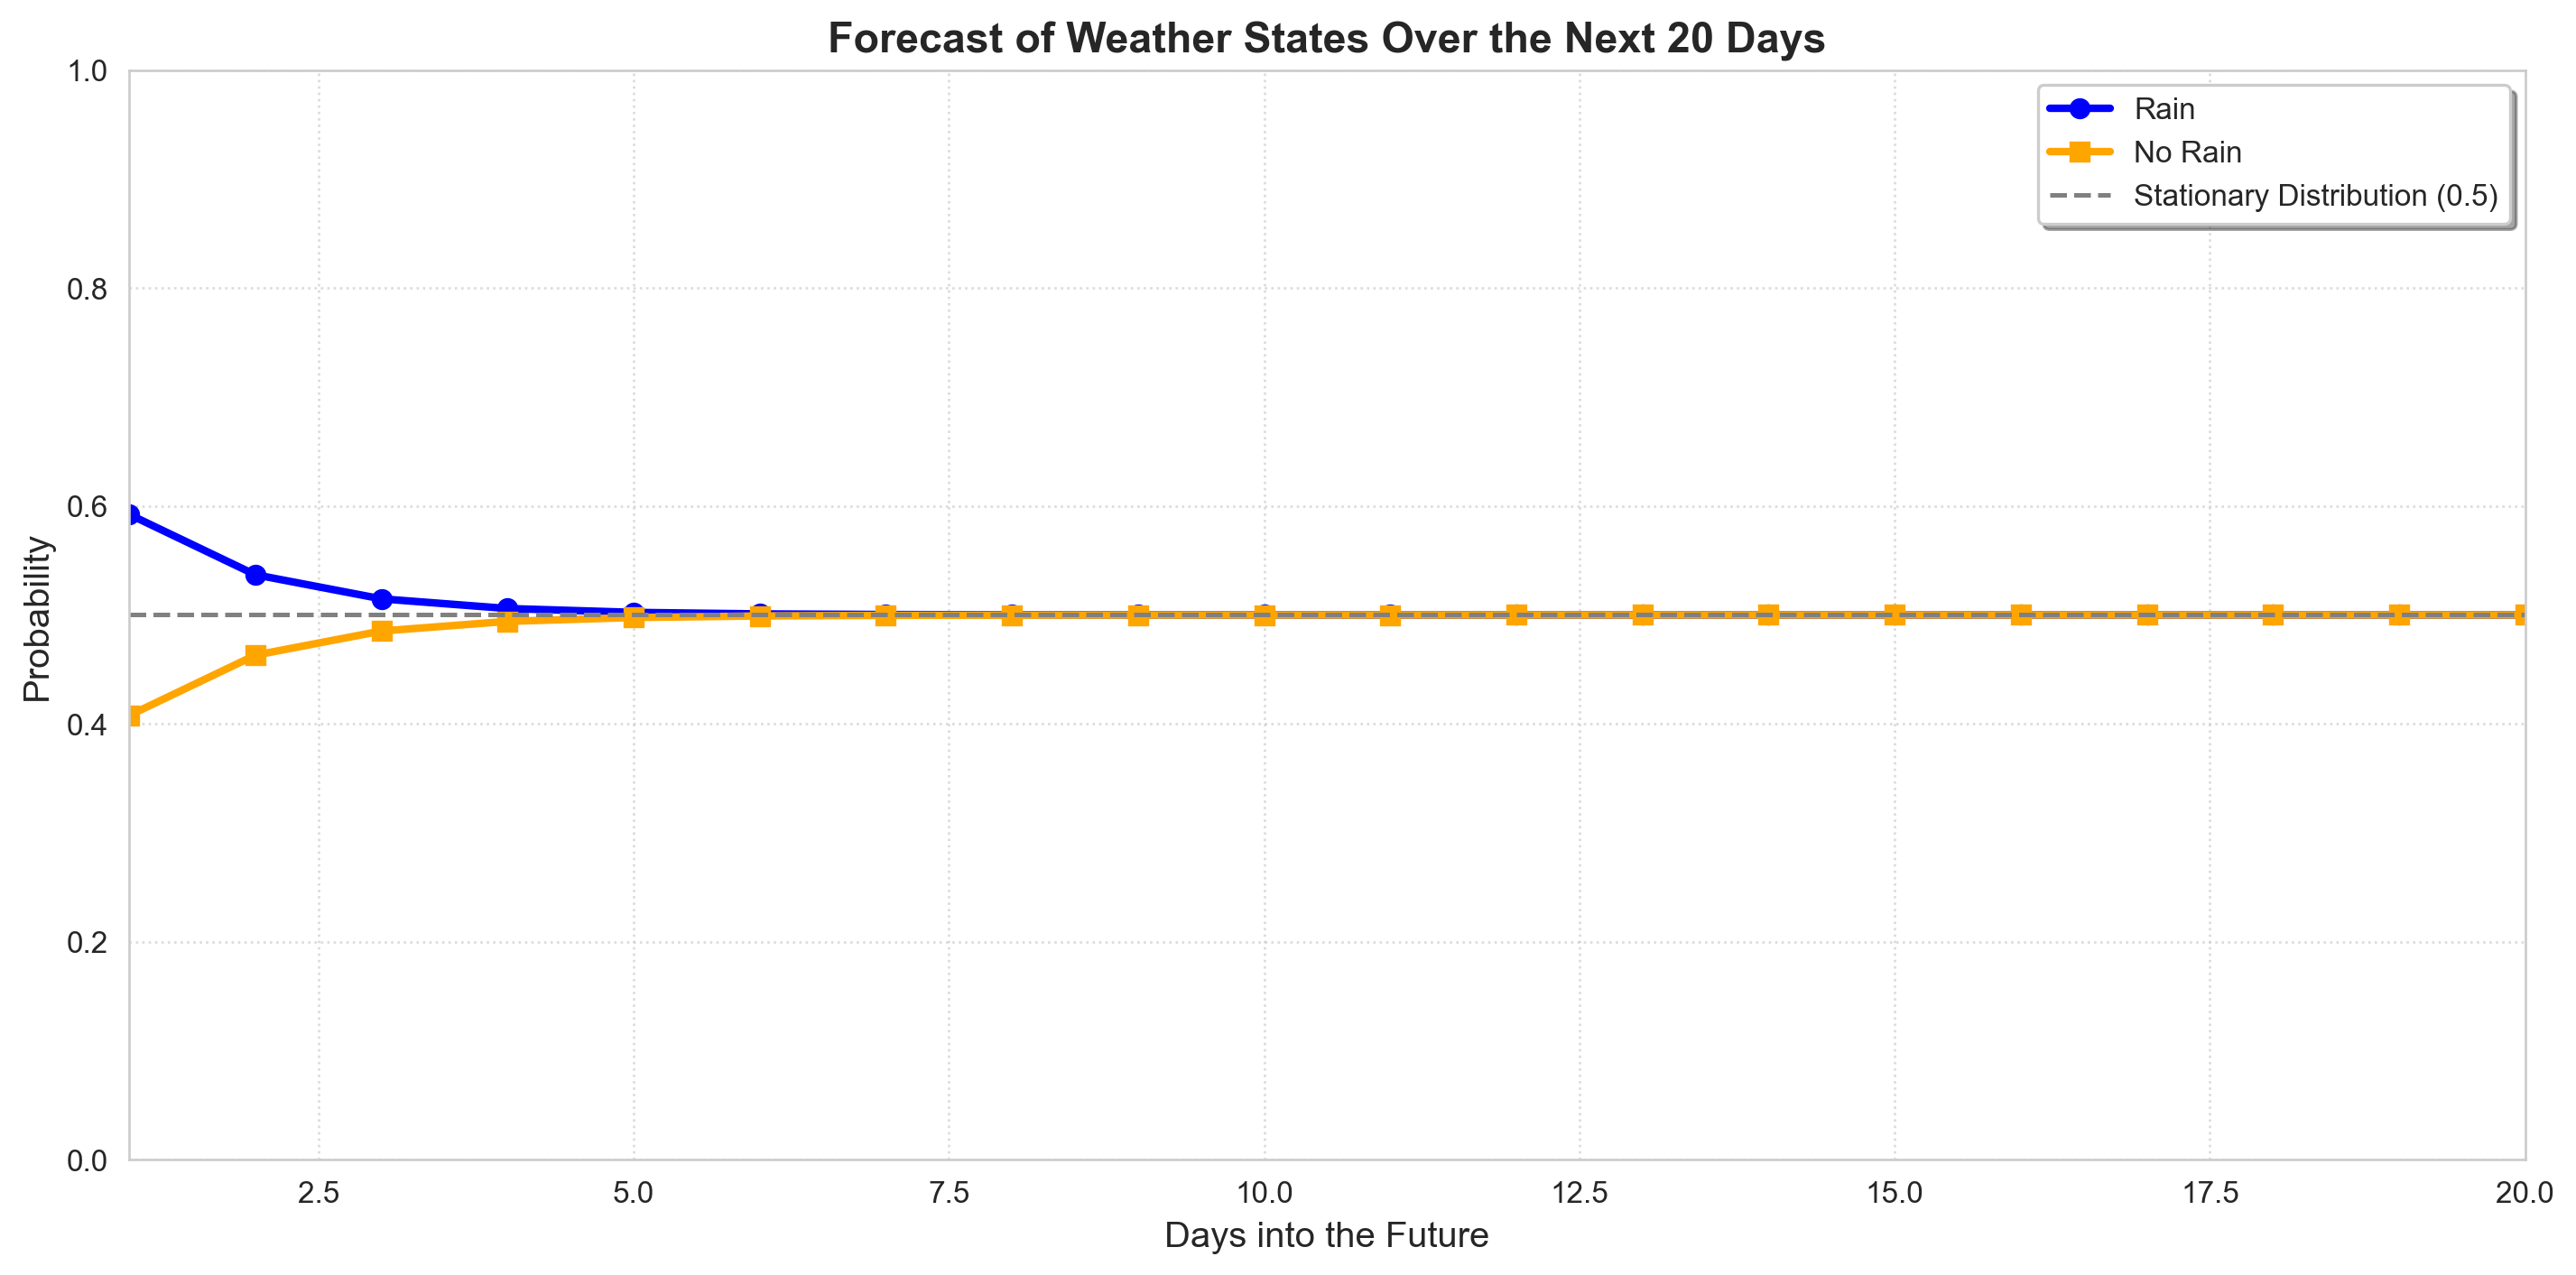

In [8]:
# %% Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
days = np.arange(1, N_FUTURE_DAYS + 1)
rain_probs = future_beliefs[:, 0]
no_rain_probs = future_beliefs[:, 1]

# Rule: Blue = Original (Rain), Orange = Transformed/Alternative (No Rain)
ax.plot(days, rain_probs, label="Rain", color="blue", linewidth=2.5, marker='o', markersize=6)
ax.plot(days, no_rain_probs, label="No Rain", color="orange", linewidth=2.5, marker='s', markersize=6)

# Add stationary equilibrium line
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, label="Stationary Distribution (0.5)")

# Aesthetics
ax.set_title("Forecast of Weather States Over the Next 20 Days", fontweight='bold')
ax.set_xlabel("Days into the Future")
ax.set_ylabel("Probability")
ax.set_xlim(1, N_FUTURE_DAYS)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()

# Save figure for portfolio
plt.savefig("plots/hmm_forecast.png", dpi=300, bbox_inches='tight')
plt.show()

## Summary and Critical Reflection

**Accomplishments:**
- Successfully implemented a discrete HMM from scratch using only NumPy, demonstrating proficiency in probabilistic graphical models.
- Executed the Forward algorithm (filtering) to infer latent states from noisy observations and the Viterbi algorithm (decoding) to find the maximum a posteriori (MAP) state sequence.
- Performed a multi-step forecast, correctly showcasing the model's convergence to a stationary distribution, validating the transition matrix properties.

**Key Results:**
- After observing "Umbrella" on Day 1, the model immediately adjusted the probability of Rain from 50% to 81.8%.
- The Viterbi path logically inferred Rain on the days umbrellas were observed, switching to NoRain on the dry day.
- The 20-day forecast demonstrated that, without new evidence, the model reverts to its long-term equilibrium (50/50), given the symmetric transition matrix.

**Suggested Next Steps for Portfolio Enhancement:**
1. **Real-World Data Integration**: Replace synthetic data with actual weather and umbrella sales data (e.g., from Kaggle) to demonstrate data ingestion and real-world applicability.
2. **Parameter Learning (Baum-Welch)**: Extend the class with an `EM` (Expectation-Maximization) method to estimate transition/emission matrices directly from unlabeled observation sequences.
3. **Comparative Analysis**: Generate synthetic sequences from the model and benchmark the Viterbi accuracy against a baseline heuristic (e.g., majority vote) to quantitatively prove the model's predictive power.

*This notebook demonstrates a rigorous, production-ready approach to stochastic temporal modeling.*